# Plot Classwise Covariance Matrices
Load and visualize the classwise covariance matrices saved during validation.

In [220]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import re

## Load the saved covariance matrices

In [221]:
# Set the path to your experiment directory

def load_covariances(dataset, model, model_path):
    if model == "scbm_residual":
        covariance_file_name = "classwise_covariances_residual.pt"
    else:
        covariance_file_name = "classwise_covariances.pt"
    
    
    cov_file = os.path.join("experiments", model, dataset, model_path, covariance_file_name)
    if os.path.exists(cov_file):
        classwise_covariances = torch.load(cov_file)
        print(f"Loaded covariances for {len(classwise_covariances)} classes")
        print(f"Class IDs: {sorted(classwise_covariances.keys())}")
        return classwise_covariances
    else:
        raise FileNotFoundError(f"File not found: {cov_file}")

    
def cov_to_corr(cov_matrix):
    """Convert covariance matrix to correlation matrix."""
    if hasattr(cov_matrix, "numpy"):
        cov_matrix = cov_matrix.numpy()
    std = np.sqrt(np.diag(np.diag(cov_matrix)))
    corr = np.linalg.inv(std) @ cov_matrix @ np.linalg.inv(std)
    return corr


# Get the number of classes and concepts
def plot(classwise_covariances, model_name, num_classes_plot=None):
    if num_classes_plot is None:
        num_classes_plot = len(classwise_covariances)
    n_classes = num_classes_plot 
    n_cols = min(4, n_classes)
    n_rows = int(np.ceil(n_classes / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows),
        squeeze=False,
    )
    sns.set_theme(style="white")

    # Turn off all axes initially
    for axis in axes.flat:
        axis.axis("off")

    # Plot each class's covariance matrix
    ordered_items = sorted(classwise_covariances.items(), key=lambda item: item[0])
    for plot_idx, (class_id, cov_matrix) in enumerate(ordered_items):
        if plot_idx >= n_classes:
            break  # Only plot up to n_classes
        axis = axes.flat[plot_idx]
        axis.axis("on")

        # Convert to numpy if needed
        if hasattr(cov_matrix, "detach"):
            cov_matrix = cov_matrix.detach().cpu().numpy()
        else:
            cov_matrix = np.asarray(cov_matrix)

        # Plot heatmap
        sns.heatmap(
            cov_matrix,
            ax=axis,
            cmap="coolwarm",
            square=True,
            vmin=float(np.nanmin(cov_matrix)),
            vmax=float(np.nanmax(cov_matrix)),
            cbar=True,
        )
        axis.set_title(f"Class {class_id}", fontsize=12, fontweight="bold")
        axis.tick_params(axis="x", rotation=45, labelsize=8)
        axis.tick_params(axis="y", rotation=0, labelsize=8)

    # Turn off unused subplots
    for axis in axes.flat[n_classes:]:
        axis.axis("off")
    
    
    fig.suptitle(f"Classwise Covariance Matrices - {model_name}", fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()



In [243]:
def dataset_info(dataset, model, model_path):
    log_file_path = os.path.join("experiments", model, dataset, model_path, "log.txt")
    with open(log_file_path, "r") as f:
        lines = f.readlines()
        info = {}
        for line_num, line in enumerate(lines):
            if line_num == 0:
                continue
            if "Epoch" in line:
                break
            
            if ":" in line:
                key, value = line.split(":", 1)
                info[key.strip()] = value.strip()
    return info


def test_metrics(dataset, model, model_path):
    metrics = {}
    with open(os.path.join("experiments", model, dataset, model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
        metrics["y_accuracy"] = float(y_accuracy)
        metrics["c_accuracy"] = float(c_accuracy)
        metrics["c_auc"] = float(c_auc)
    return metrics   


def get_dataset(dataset, model, model_path):
    log_file_path = os.path.join("experiments", model, dataset, model_path, "log.txt")
    with open(log_file_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            if "data_dir:" in line:
                data_dir_line = line
                break
        data_dir = data_dir_line.split("data_dir:")[1].strip()
    local_data_root = "datasets"
    
    if data_dir.startswith("/cluster/"):
        local_root = "datasets"
        relative_path = "/".join(data_dir.split("/")[-2:])
        data_dir = os.path.join(local_root, relative_path)
    
    return data_dir

data_dir = get_dataset("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_1.0_gamma_0_rho_0_200_epochs_2026-05-26_17-02-31_5ab20")
print(f"{data_dir}")
        

datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0_seed_0


## Plot covariance matrices

In [250]:
s = torch.load("datasets/synthetic_res_scbm/local_a_1.0_b_1.0_g_0_rho_0_seed_0_v9/test/s.pt")
print(s)
print(s.shape)
log_file = "/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/scbm_residual/synthetic_res_scbm/alpha_1.0_beta_1.0_gamma_0_rho_0_DELETE_2026-05-27_12-39-35_8261a/log.txt"
os.path.dirname(log_file)

tensor([-0.2151, -0.2695, -0.5447,  ..., -0.8524, -1.1819, -0.2151])
torch.Size([10000])


'/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/scbm_residual/synthetic_res_scbm/alpha_1.0_beta_1.0_gamma_0_rho_0_DELETE_2026-05-27_12-39-35_8261a'

Loaded covariances for 2 classes
Class IDs: [0, 1]
Concepts linked to residuals (concept index, residual index): [(3, 0), (8, 4)]
Task weight s for concepts: tensor([ 0.0000,  0.0000,  0.0300,  0.6372, -0.7701,  0.0000,  0.0000,  0.0000, 0.0000,  0.0000])
Task weight s for residuals: tensor([ 0.0000,  0.0000,  0.0000, -0.8824,  0.4705])
rho_cr (correlation between linked concepts and residuals): 0
alpha: 1.0, beta: 1.0, gamma: 0
y_accuracy: 0.732
c_accuracy: 0.864
c_auc: 0.944


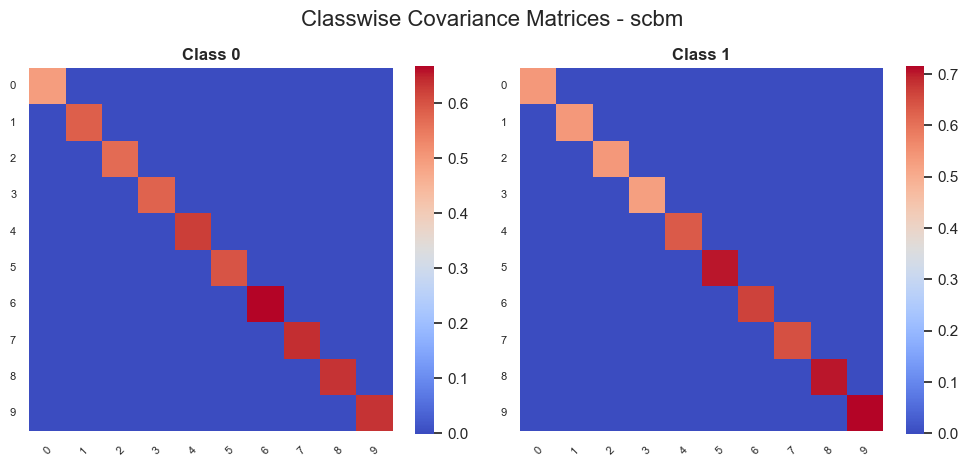

Loaded covariances for 2 classes
Class IDs: [0, 1]
Concepts linked to residuals (concept index, residual index): [(3, 0), (8, 4)]
Task weight s for concepts: tensor([ 0.0000,  0.0000,  0.0300,  0.6372, -0.7701,  0.0000,  0.0000,  0.0000, 0.0000,  0.0000])
Task weight s for residuals: tensor([ 0.0000,  0.0000,  0.0000, -0.8824,  0.4705])
rho_cr (correlation between linked concepts and residuals): 0
alpha: 1.0, beta: 1.0, gamma: 0
y_accuracy: 0.817
c_accuracy: 0.87
c_auc: 0.949


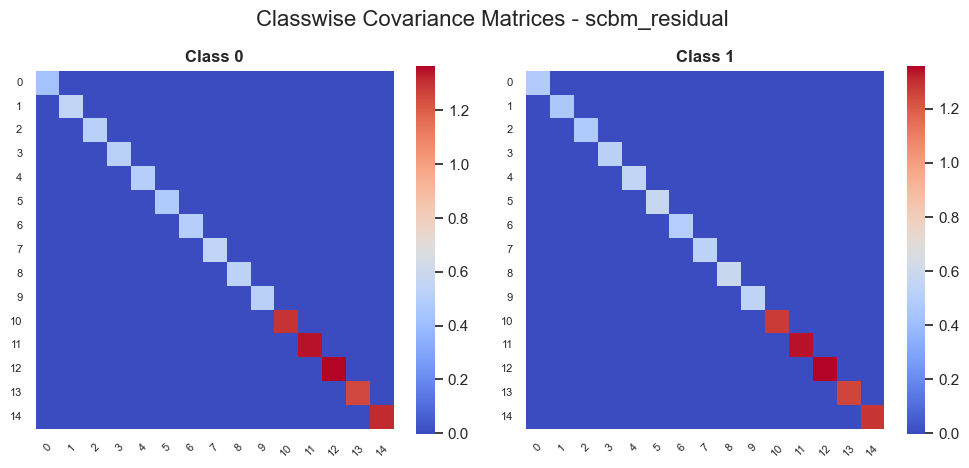

In [ ]:
models = [("synthetic_res_scbm", "scbm", "synthetic_res_scbm_200_epochs_2026-05-20_16-03-18_fcbad"),
          ("synthetic_res_scbm", "scbm_residual", "synthetic_res_scbm_200_epochs_2026-05-20_16-03-20_2df95")]

for dataset, model, model_path in models:
    covariance_matrices = load_covariances(dataset, model, model_path)
    info = dataset_info(dataset, model, model_path)
    for key, value in info.items():
        print(f"{key}: {value}")
    metrics = test_metrics(dataset, model, model_path)
    print("\nTest metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value}")
    plot(covariance_matrices, model_name=model)
    
    
    



## Plot correlation matrices instead

synthetic_res_scbm scbm synthetic_res_scbm_200_epochs_2026-05-20_16-03-18_fcbad
Loaded covariances for 2 classes
Class IDs: [0, 1]


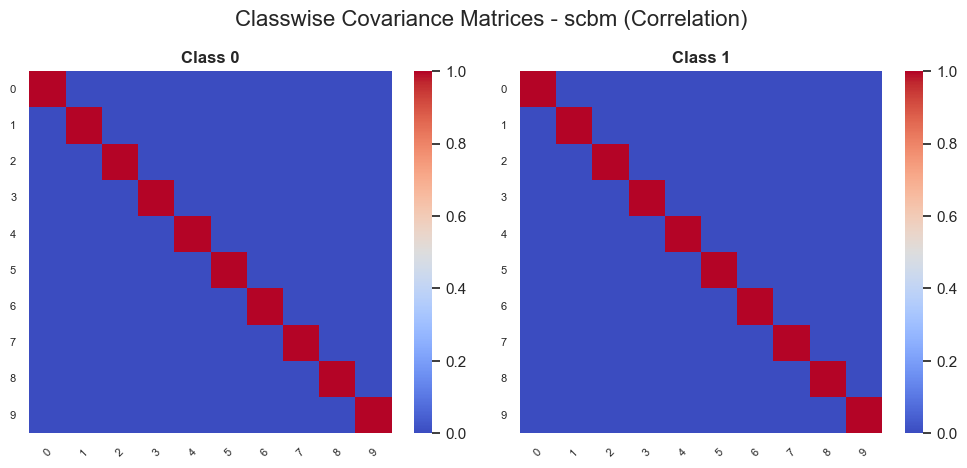

synthetic_res_scbm scbm_residual synthetic_res_scbm_200_epochs_2026-05-20_16-03-20_2df95
Loaded covariances for 2 classes
Class IDs: [0, 1]


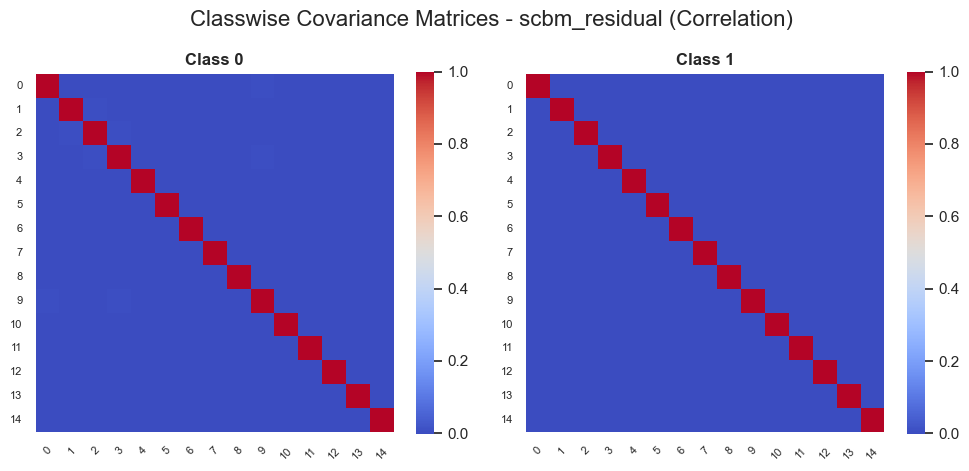

In [224]:
models = [("synthetic_res_scbm", "scbm", "synthetic_res_scbm_200_epochs_2026-05-20_16-03-18_fcbad"),
          ("synthetic_res_scbm", "scbm_residual", "synthetic_res_scbm_200_epochs_2026-05-20_16-03-20_2df95")]

for dataset, model, model_path in models:
    print(dataset, model, model_path)
    covariance_matrices = load_covariances(dataset, model, model_path)
    correlation_matrices = {i: cov_to_corr(cov) for i, cov in covariance_matrices.items()}
    plot(correlation_matrices, model_name=model + " (Correlation)")
    

# Model weight analysis

In [225]:
from omegaconf import OmegaConf
import ast
from models.models import create_model


def get_config_dict(dataset, model, model_path):
    log_file = os.path.join("experiments", model, dataset, model_path, "log.txt")
    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            lines = f.readlines()
            info_dict = lines[0].strip()  
            info_dict =  ast.literal_eval(info_dict)
            
        return info_dict
    else:
        raise FileNotFoundError(f"Log file not found: {log_file}")
    
    


def get_final_layer_weights(dataset, model_name, model_path):
    full_model_path = os.path.join("experiments", model_name, dataset, model_path, "model.pth")
    if os.path.exists(full_model_path):
        model_state = torch.load(full_model_path, map_location=torch.device('cpu'))
        config_dict = get_config_dict(dataset, model_name, model_path)
        config = OmegaConf.create(config_dict)
        model = create_model(config)
        model.load_state_dict(model_state)
        print(f"Loaded model from {full_model_path}")
        W = model.head[0].weight.detach().cpu()
        W_c = W[:, :config.data.num_concepts]
        if model_name == "scbm_residual":
            W_r = W[:, config.data.num_concepts:]
        else:
            W_r = None  
        return W_c, W_r
    else:
        raise FileNotFoundError(f"Model file not found: {full_model_path}")

In [226]:
models = [("synthetic_res_scbm", "scbm", "synthetic_res_scbm_200_epochs_2026-05-20_16-03-18_fcbad"),
          ("synthetic_res_scbm", "scbm_residual", "synthetic_res_scbm_200_epochs_2026-05-20_16-03-20_2df95")]

for dataset, model, model_path in models:
    print(f"\n--- New model: {model} ---")
    info = dataset_info(dataset, model, model_path)
    for key, value in info.items():
        print(f"{key}: {value}")
    if model == "scbm_residual":
        W_c, W_r = get_final_layer_weights(dataset, model, model_path)
        print(f"W_c shape: {W_c.shape}, W_r shape: {W_r.shape}")
        print("W_c:", W_c)
        print("W_r:", W_r)
    elif model == "scbm":
        W_c,_ = get_final_layer_weights(dataset, model, model_path)
        #print(f"W_c shape: {W_c.shape}")
        print("W_c:", W_c)

        
    
    


--- New model: scbm ---
Concepts linked to residuals (concept index, residual index): [(3, 0), (8, 4)]
Task weight s for concepts: tensor([ 0.0000,  0.0000,  0.0300,  0.6372, -0.7701,  0.0000,  0.0000,  0.0000, 0.0000,  0.0000])
Task weight s for residuals: tensor([ 0.0000,  0.0000,  0.0000, -0.8824,  0.4705])
rho_cr (correlation between linked concepts and residuals): 0
alpha: 1.0, beta: 1.0, gamma: 0
Using SCBM model!
Loaded model from experiments/scbm/synthetic_res_scbm/synthetic_res_scbm_200_epochs_2026-05-20_16-03-18_fcbad/model.pth
W_c: tensor([[ 1.2029e-02, -6.6426e-02,  2.5785e-02,  2.1396e+00, -2.2492e+00,
         -4.9226e-02,  2.6901e-02,  1.4021e-03,  1.0826e-02, -3.5994e-02]])

--- New model: scbm_residual ---
Concepts linked to residuals (concept index, residual index): [(3, 0), (8, 4)]
Task weight s for concepts: tensor([ 0.0000,  0.0000,  0.0300,  0.6372, -0.7701,  0.0000,  0.0000,  0.0000, 0.0000,  0.0000])
Task weight s for residuals: tensor([ 0.0000,  0.0000,  0.000

# Correlation between residual dimensions and task head weights

In [227]:
def corr_matrix(A, B, eps=1e-8):
    """
    A: Tensor of shape (N, d_a)
    B: Tensor of shape (N, d_b)

    Returns:
        Correlation matrix of shape (d_a, d_b)
        entry[j, k] = corr(A[:, j], B[:, k])
    """
    A = A.detach().cpu().float()
    B = B.detach().cpu().float()

    A = A - A.mean(dim=0, keepdim=True)
    B = B - B.mean(dim=0, keepdim=True)

    A = A / (A.std(dim=0, keepdim=True) + eps)
    B = B / (B.std(dim=0, keepdim=True) + eps)

    return (A.T @ B) / (A.shape[0] - 1)


--- New model: scbm_residual ---
Config dict: {'experiment_name': 'experiments', 'experiment_dir': '/cluster/home/smarcou/work/experiments_scbm/scbm_residual/synthetic_res_scbm/synthetic_res_scbm_200_epochs_2026-05-20_16-03-20_2df95', 'seed': 0, 'workers': 2, 'save_model': True, 'train_only': True, 'incomplete': False, 'run_inference': False, 'run_interventions': False, 'num_attribute_groups_remove': 14, 'remove_attribute_groups': False, 'ratio_attributes_remove': 0.5, 'hyperparameter_search': False, 'save_name': '200_epochs', 'logging': {'project': 'SCBM', 'mode': 'disabled', 'entity': 'your_entity'}, 'inference': {'ex_name': None, 'save_concept_target_pred': False}, 'model': {'model_directory': '/cluster/home/smarcou/work/pretrained_networks/', 'head_arch': 'linear', 'alpha': 1.0, 'encoder_arch': 'FCNN', 'training_mode': 'joint', 'validate_per_epoch': 30, 'learning_rate': 0.0001, 'optimizer': 'adam', 'decrease_every': 150, 'lr_divisor': 2, 'weight_decay': 0, 'train_batch_size': 64, 

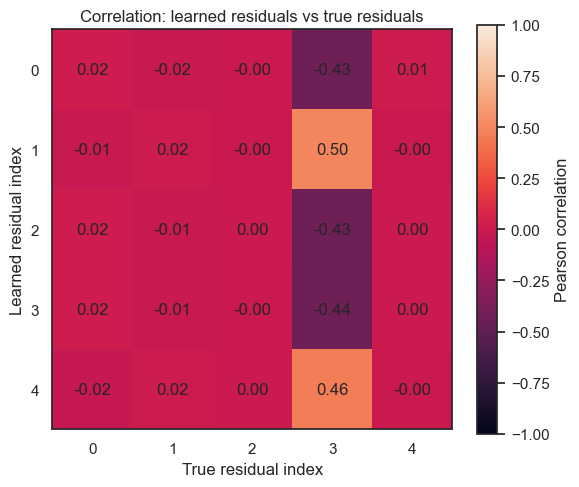


Dataset and training info:
Task weight s for residuals: tensor([ 0.0000,  0.0000,  0.0000, -0.8824,  0.4705])


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt


models = [
    ("synthetic_res_scbm", "scbm_residual", "synthetic_res_scbm_200_epochs_2026-05-20_16-03-20_2df95")
]

data_path = os.path.join(
    "datasets",
    "synthetic_res_scbm",
    "local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4",
)


def corr_matrix(A, B, eps=1e-8):
    """
    A: Tensor of shape (N, d_a)
    B: Tensor of shape (N, d_b)

    Returns:
        Correlation matrix of shape (d_a, d_b)
        entry[j, k] = corr(A[:, j], B[:, k])
    """
    A = A.detach().cpu().float()
    B = B.detach().cpu().float()

    A = A - A.mean(dim=0, keepdim=True)
    B = B - B.mean(dim=0, keepdim=True)

    A = A / (A.std(dim=0, keepdim=True) + eps)
    B = B / (B.std(dim=0, keepdim=True) + eps)


    return (A.T @ B) / (A.shape[0] - 1)


for dataset, model, model_path in models:
    print(f"\n--- New model: {model} ---")

    model_dir = os.path.join("experiments", model, dataset, model_path)
    
    config_dict = get_config_dict(dataset, model, model_path)
    num_concepts = config_dict["data"]["num_concepts"]
    
    
    
    print(f"Config dict: {config_dict}")

    predicted_concepts_residuals_probs_mcmc = torch.load(
        os.path.join(model_dir, "pred_concepts_residuals_probs.pt"),
        map_location="cpu",
    )

    predicted_residuals_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, num_concepts:, :]
    predicted_concepts_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, :num_concepts, :]

    true_concepts_residuals = torch.load(
        os.path.join(data_path, "test", "concepts_residuals.pt"),
        map_location="cpu",
    )
    
    
    
    true_residuals = torch.load(
        os.path.join(data_path, "test", "residuals.pt"),
        map_location="cpu",
    )
    
    

    print(f"Predicted residuals probabilities shape: {predicted_residuals_probs_mcmc.shape}")
    print(f"True residuals shape: {true_residuals.shape}")
    print(f"Predicted concepts probabilities shape: {predicted_concepts_probs_mcmc.shape}")
    print(f"True concepts residuals shape: {true_concepts_residuals.shape}")



    # ------------------------------------------------------------
    # 1. Average over Monte Carlo samples
    # ------------------------------------------------------------
    # predicted_residuals_probs_mcmc: (N_test, num_residuals, num_monte_carlo)
    # predicted_residuals_probs:      (N_test, num_residuals)
    predicted_residuals_probs = predicted_residuals_probs_mcmc.mean(dim=2)
    predicted_concepts_probs = predicted_concepts_probs_mcmc.mean(dim=2)

    print(f"Predicted residuals probabilities after MC mean: {predicted_residuals_probs.shape}")
    print(f"Predicted concepts probabilities after MC mean: {predicted_concepts_probs.shape}")

    # ------------------------------------------------------------
    # 2. Compute correlation matrix
    # ------------------------------------------------------------
    corr_pred_true_residuals = corr_matrix(
        predicted_residuals_probs,
        true_residuals,
    )

    print("\nCorrelation between learned residuals and true residuals:")
    print(corr_pred_true_residuals)

    # Absolute correlation is often easier to inspect because dimensions may flip sign
    abs_corr_pred_true_residuals = corr_pred_true_residuals.abs()

    print("\nAbsolute correlation between learned residuals and true residuals:")
    print(abs_corr_pred_true_residuals)

    # ------------------------------------------------------------
    # 3. For each learned residual, find best matching true residual
    # ------------------------------------------------------------
    best_true_idx = abs_corr_pred_true_residuals.argmax(dim=1)
    best_true_corr = abs_corr_pred_true_residuals.max(dim=1).values

    print("\nBest matching true residual for each learned residual:")
    for learned_j in range(predicted_residuals_probs.shape[1]):
        print(
            f"learned residual {learned_j} "
            f"best matches true residual {best_true_idx[learned_j].item()} "
            f"with |corr| = {best_true_corr[learned_j].item():.3f}"
        )

    # ------------------------------------------------------------
    # 4. For each true residual, find best matching learned residual
    # ------------------------------------------------------------
    best_learned_idx = abs_corr_pred_true_residuals.argmax(dim=0)
    best_learned_corr = abs_corr_pred_true_residuals.max(dim=0).values

    print("\nBest matching learned residual for each true residual:")
    for true_k in range(true_residuals.shape[1]):
        print(
            f"true residual {true_k} "
            f"best matches learned residual {best_learned_idx[true_k].item()} "
            f"with |corr| = {best_learned_corr[true_k].item():.3f}"
        )

    # ------------------------------------------------------------
    # 5. Plot correlation heatmap
    # ------------------------------------------------------------
    plt.figure(figsize=(6, 5))
    plt.imshow(corr_pred_true_residuals.numpy(), vmin=-1, vmax=1)
    plt.colorbar(label="Pearson correlation")

    plt.xlabel("True residual index")
    plt.ylabel("Learned residual index")
    plt.title("Correlation: learned residuals vs true residuals")

    plt.xticks(np.arange(true_residuals.shape[1]))
    plt.yticks(np.arange(predicted_residuals_probs.shape[1]))

    for i in range(corr_pred_true_residuals.shape[0]):
        for j in range(corr_pred_true_residuals.shape[1]):
            plt.text(
                j,
                i,
                f"{corr_pred_true_residuals[i, j].item():.2f}",
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 6. Print dataset info
    # ------------------------------------------------------------
    info = dataset_info(dataset, model, model_path)
    print("\nDataset and training info:")
    print(f"Task weight s for residuals: {info['Task weight s for residuals']}")


In [233]:
def corr_matrix(A, B, eps=1e-8):
    """
    A: Tensor of shape (N, d_a)
    B: Tensor of shape (N, d_b)

    Returns:
        Correlation matrix of shape (d_a, d_b)
        entry[j, k] = corr(A[:, j], B[:, k])
    """
    A = A.detach().cpu().float()
    B = B.detach().cpu().float()

    A = A - A.mean(dim=0, keepdim=True)
    B = B - B.mean(dim=0, keepdim=True)

    A = A / (A.std(dim=0, keepdim=True) + eps)
    B = B / (B.std(dim=0, keepdim=True) + eps)


    return (A.T @ B) / (A.shape[0] - 1)


# ------------------------------------------------------------
# Helper function for plotting
# ------------------------------------------------------------
def plot_corr_heatmap(corr, x_label, y_label, title, figsize=(7, 5)):
    corr = corr.detach().cpu()

    plt.figure(figsize=figsize)
    plt.imshow(corr.numpy(), vmin=-1, vmax=1)
    plt.colorbar(label="Pearson correlation")

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    plt.xticks(np.arange(corr.shape[1]))
    plt.yticks(np.arange(corr.shape[0]))

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            plt.text(
                j,
                i,
                f"{corr[i, j].item():.2f}",
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.show()



--- New model: scbm_residual ---
Config dict: {'experiment_name': 'experiments', 'experiment_dir': '/cluster/home/smarcou/work/experiments_scbm/scbm_residual/synthetic_res_scbm/synthetic_res_scbm_200_epochs_2026-05-20_16-03-20_2df95', 'seed': 0, 'workers': 2, 'save_model': True, 'train_only': True, 'incomplete': False, 'run_inference': False, 'run_interventions': False, 'num_attribute_groups_remove': 14, 'remove_attribute_groups': False, 'ratio_attributes_remove': 0.5, 'hyperparameter_search': False, 'save_name': '200_epochs', 'logging': {'project': 'SCBM', 'mode': 'disabled', 'entity': 'your_entity'}, 'inference': {'ex_name': None, 'save_concept_target_pred': False}, 'model': {'model_directory': '/cluster/home/smarcou/work/pretrained_networks/', 'head_arch': 'linear', 'alpha': 1.0, 'encoder_arch': 'FCNN', 'training_mode': 'joint', 'validate_per_epoch': 30, 'learning_rate': 0.0001, 'optimizer': 'adam', 'decrease_every': 150, 'lr_divisor': 2, 'weight_decay': 0, 'train_batch_size': 64, 

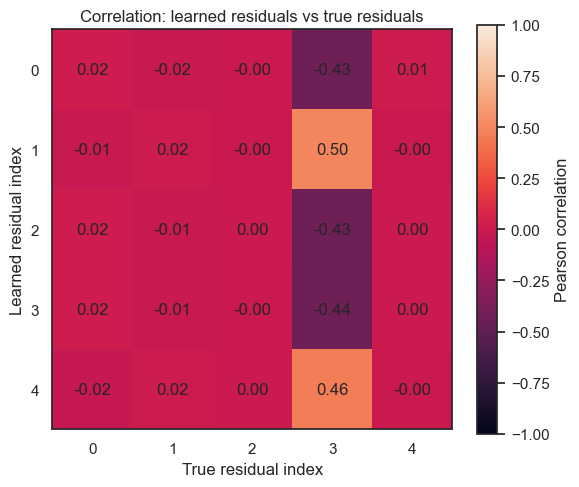

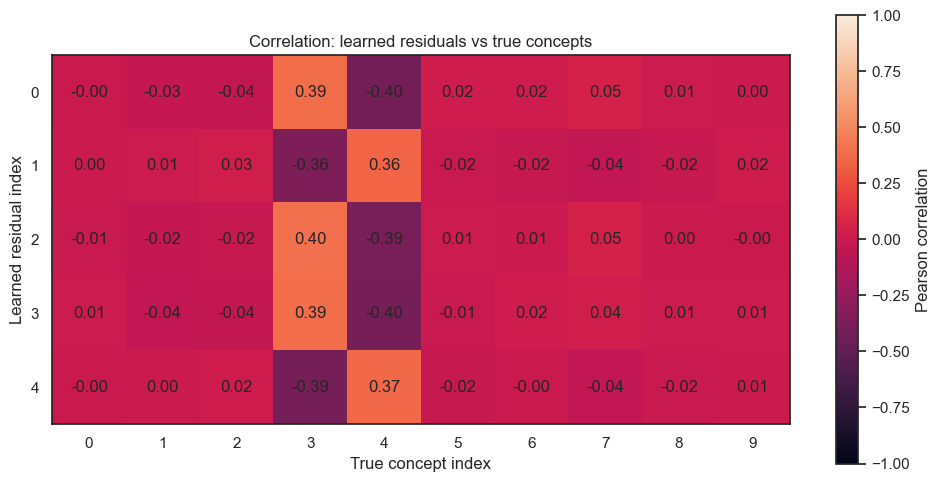

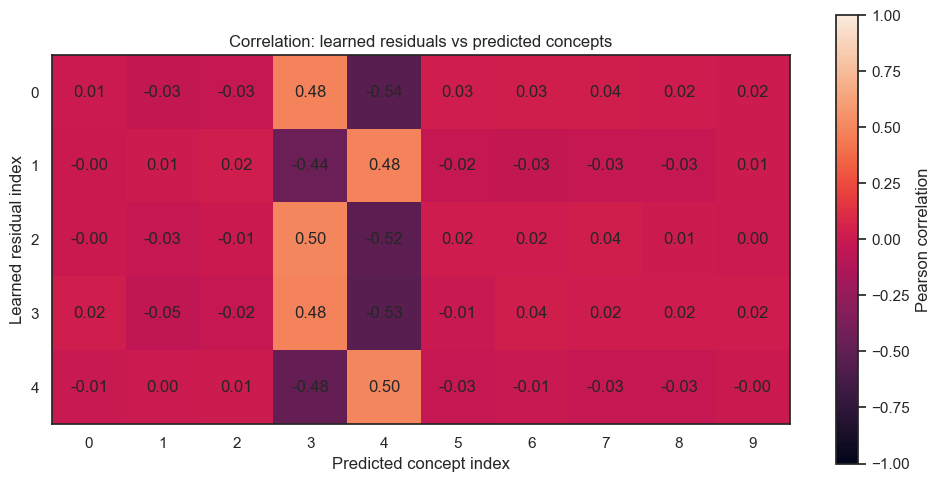


Max |corr| between learned residuals and true residuals:
tensor([0.4303, 0.4970, 0.4326, 0.4369, 0.4576])

Max |corr| between learned residuals and true concepts:
tensor([0.4042, 0.3583, 0.4022, 0.3983, 0.3913])

Max |corr| between learned residuals and predicted concepts:
tensor([0.5383, 0.4814, 0.5179, 0.5323, 0.4998])

Dataset and training info:
Task weight s for residuals: tensor([ 0.0000,  0.0000,  0.0000, -0.8824,  0.4705])
Task weight s for concepts: tensor([ 0.0000,  0.0000,  0.0300,  0.6372, -0.7701,  0.0000,  0.0000,  0.0000, 0.0000,  0.0000])


In [240]:
for dataset, model, model_path in models:
    print(f"\n--- New model: {model} ---")

    model_dir = os.path.join("experiments", model, dataset, model_path)
    
    config_dict = get_config_dict(dataset, model, model_path)
    num_concepts = config_dict["data"]["num_concepts"]
    
    
    
    print(f"Config dict: {config_dict}")

    predicted_concepts_residuals_probs_mcmc = torch.load(
        os.path.join(model_dir, "pred_concepts_residuals_probs.pt"),
        map_location="cpu",
    )

    predicted_residuals_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, num_concepts:, :]
    predicted_concepts_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, :num_concepts, :]

    true_concepts = torch.load(
        os.path.join(data_path, "test", "concepts.pt"),
        map_location="cpu",
    )
    
    
    
    true_residuals = torch.load(
        os.path.join(data_path, "test", "residuals.pt"),
        map_location="cpu",
    )
    
    

    print(f"Predicted residuals probabilities shape: {predicted_residuals_probs_mcmc.shape}")
    print(f"True residuals shape: {true_residuals.shape}")
    print(f"Predicted concepts probabilities shape: {predicted_concepts_probs_mcmc.shape}")
    print(f"True concepts shape: {true_concepts.shape}")
    
    

    # ------------------------------------------------------------
    # Average over Monte Carlo samples
    # ------------------------------------------------------------
    # predicted_residuals_probs_mcmc: (N_test, num_residuals, num_monte_carlo)
    # predicted_residuals_probs:      (N_test, num_residuals)
    predicted_residuals_probs = predicted_residuals_probs_mcmc.mean(dim=2)
    predicted_concepts_probs = predicted_concepts_probs_mcmc.mean(dim=2)


    # ------------------------------------------------------------
    # Compute correlation matrices
    # ------------------------------------------------------------
    corr_pred_res_true_res = corr_matrix(
        predicted_residuals_probs,
        true_residuals,
    )

    corr_pred_res_true_concepts = corr_matrix(
        predicted_residuals_probs,
        true_concepts,
    )

    corr_pred_res_pred_concepts = corr_matrix(
        predicted_residuals_probs,
        predicted_concepts_probs,
    )




    # ------------------------------------------------------------
    # Plot 1: learned residuals vs true residuals
    # ------------------------------------------------------------
    plot_corr_heatmap(
        corr_pred_res_true_res,
        x_label="True residual index",
        y_label="Learned residual index",
        title="Correlation: learned residuals vs true residuals",
        figsize=(6, 5),
    )


    # ------------------------------------------------------------
    # Plot 2: learned residuals vs true observed concepts
    # ------------------------------------------------------------
    plot_corr_heatmap(
        corr_pred_res_true_concepts,
        x_label="True concept index",
        y_label="Learned residual index",
        title="Correlation: learned residuals vs true concepts",
        figsize=(10, 5),
    )


    # ------------------------------------------------------------
    # Plot 3: learned residuals vs predicted concepts
    # ------------------------------------------------------------
    plot_corr_heatmap(
        corr_pred_res_pred_concepts,
        x_label="Predicted concept index",
        y_label="Learned residual index",
        title="Correlation: learned residuals vs predicted concepts",
        figsize=(10, 5),
    )


    # ------------------------------------------------------------
    # Optional: print maximum absolute correlations
    # ------------------------------------------------------------
    print("\nMax |corr| between learned residuals and true residuals:")
    print(corr_pred_res_true_res.abs().max(dim=1).values)

    print("\nMax |corr| between learned residuals and true concepts:")
    print(corr_pred_res_true_concepts.abs().max(dim=1).values)

    print("\nMax |corr| between learned residuals and predicted concepts:")
    print(corr_pred_res_pred_concepts.abs().max(dim=1).values)
    
        # ------------------------------------------------------------
    # 6. Print dataset info
    # ------------------------------------------------------------
    info = dataset_info(dataset, model, model_path)
    print("\nDataset and training info:")
    print(f"Task weight s for residuals: {info['Task weight s for residuals']}")
    print(f"Task weight s for concepts: {info['Task weight s for concepts']}")

# Check datasets

In [238]:
root = "datasets/synthetic_res_scbm"
data1 = "local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4"
data2 = "local_a_1.0_b_1.0_g_0_rho_0_seed_0_v5"

datasets = [data1, data2]
splits = ["train", "val", "test"]

data_dict = {}

for data_dir in datasets:
    for split in splits:
        if not os.path.exists(os.path.join(root, data_dir, split)):
            print(f"Directory not found: {os.path.join(root, data_dir, split)}")
            continue
        print(f"Loading data from {data_dir} for split {split}")
        x_path = os.path.join(root, data_dir, split, "x.pt")
        print(f"Loading x from {x_path}")
        y_path = os.path.join(root, data_dir, split, "y.pt")
        x = torch.load(x_path)
        y = torch.load(y_path)
        print(x.shape, y.shape)
        data_dict[(data_dir, split)] = (x, y)
        
for split in splits:
    x1, y1 = data_dict[(data1, split)]
    x2, y2 = data_dict[(data2, split)]
    # Check if x1 and x2 are the same
    if torch.allclose(x1, x2):
        print(f"x tensors are the same for split {split}")
    else:
        print(f"x tensors differ for split {split}")
    # Check if y1 and y2 are the same
    if torch.allclose(y1, y2):
        print(f"y tensors are the same for split {split}")
    else:
        print(f"y tensors differ for split {split}")
    


Loading data from local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4 for split train
Loading x from datasets/synthetic_res_scbm/local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4/train/x.pt
torch.Size([30000, 100]) torch.Size([30000])
Loading data from local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4 for split val
Loading x from datasets/synthetic_res_scbm/local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4/val/x.pt
torch.Size([10000, 100]) torch.Size([10000])
Loading data from local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4 for split test
Loading x from datasets/synthetic_res_scbm/local_a_1.0_b_1.0_g_0_rho_0_seed_0_v4/test/x.pt
torch.Size([10000, 100]) torch.Size([10000])
Loading data from local_a_1.0_b_1.0_g_0_rho_0_seed_0_v5 for split train
Loading x from datasets/synthetic_res_scbm/local_a_1.0_b_1.0_g_0_rho_0_seed_0_v5/train/x.pt
torch.Size([30000, 100]) torch.Size([30000])
Loading data from local_a_1.0_b_1.0_g_0_rho_0_seed_0_v5 for split val
Loading x from datasets/synthetic_res_scbm/local_a_1.0_b_1.0_g_0_rho_0_seed_0_v5/val/x.pt
torch.Size